# scale_hcm = 16

Import Libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
! pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.8/750.8 kB 7.4 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.19.3-py3-none-manylinux1_x86_64.whl (166.0 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-many

In [4]:
from ultralytics import YOLO

In [5]:
import pandas as pd
import numpy as np
import cv2, os, math, pickle

Load segmentation models

In [6]:
scale_model = YOLO("/content/drive/MyDrive/Sowmya /models/Sardine/v4/scale_detection_model.pt")
fish_model = YOLO("/content/drive/MyDrive/Sowmya /models/segmentation/kartik/fish.pt")

WARNING ⚠️ /content/drive/MyDrive/Sowmya /models/Sardine/v4/scale_detection_model.pt appears to require 'dill', which is not in ultralytics requirements.
AutoInstall will run now for 'dill' but this feature will be removed in the future.
Recommend fixes are to train a new model using the latest 'ultralytics' package or to run a command with an official YOLOv8 model, i.e. 'yolo predict model=yolov8n.pt'
requirements: Ultralytics requirement ['dill'] not found, attempting AutoUpdate...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 3.0 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 10.7s, installed 1 package: ['dill']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect



In [39]:
def circumference_area(img):
    cv2.imwrite('/content/drive/MyDrive/Sowmya /fish1.png', img)
    # Load the segmented fish image
    # image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Threshold the image to create a binary mask
    _, binary_mask = cv2.threshold(image, 1, 255, cv2.THRESH_BINARY)

    # Find contours in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Ensure at least one contour was found
    if len(contours) > 0:
        # Get the largest contour (presumably the fish)
        largest_contour = max(contours, key=cv2.contourArea)

        # Calculate the circumference of the contour
        circumference = cv2.arcLength(largest_contour, closed=True)

        # Calculate the area enclosed by the contour
        area = cv2.contourArea(largest_contour)

        return circumference, area

In [40]:
def get_segmented_img(pred, index=0):
    img_shape = pred.orig_shape
    img = pred.orig_img.copy()
    height, width = img_shape[0], img_shape[1]
    masks = pred.masks.xy
    seg_img_list = []
    for i in range(len(masks)):
        if i != index: continue
        mask = masks[i]
        mask_points = mask.astype(int)
        binary_mask = np.zeros((height, width), dtype=np.uint8)
        cv2.fillPoly(binary_mask, [mask_points], 255)
        masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
        x, y, w, h = cv2.boundingRect(mask_points)
        segment_image = np.zeros((height, width, 3), dtype=np.uint8)
        segment_image[y:y+h, x:x+w] = masked_img[y:y+h, x:x+w]
        segment_image = segment_image[y:y+h, x:x+w]
        white_background = False
        if white_background:
            black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
            segment_image[black_mask] = [255, 255, 255]
        seg_img_list.append(segment_image)
    return seg_img_list

In [41]:
def get_object_height(img_path, model, conf=0.5, iou=0.7, seg=False):
    seg_img_list = None
    results = model(img_path, conf=conf, iou=iou, verbose=False)
    if len(results[0].boxes.cls) != 0:
        index = 0
        hp = int(results[0].boxes.xywh[index][3])
        wp = int(results[0].boxes.xywh[index][2])
        dp = int(math.hypot(hp, wp))
        if hp<wp: (hp, wp) = (wp, hp)
        obj_present = True
        if seg: seg_img_list = get_segmented_img(results[0], index)
    else:
        hp, wp, dp = (0, 0, 0)
        obj_present = False
    return hp, wp, dp, obj_present, seg_img_list


def fish_measures(img_path):
    # Predict with the scale model
    scale_hp, scale_wp, scale_dp, scale, _ = get_object_height(img_path, scale_model)
    # Predict with the fish model
    fish_hp, fish_wp, fish_dp, fish, fish_img_list = get_object_height(img_path, fish_model,
                                                     conf=0.75, iou=0.7, seg=True)

    try:
        scale_hcm = 16
        one_pixel_value = scale_hcm / scale_hp
        fish_hcm = int(fish_hp * one_pixel_value)
        fish_wcm = int(fish_wp * one_pixel_value)
        fish_dcm = int(fish_dp * one_pixel_value)
        scale_dcm = int(scale_dp * one_pixel_value)
        scale_wcm = int(scale_wp * one_pixel_value)
    except:
        (fish_hcm, fish_wcm, fish_dcm,
         scale_dcm, scale_wcm, one_pixel_value) = (0, 0, 0, 0, 0, 0)

    return (fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm,
            fish, scale, fish_img_list, one_pixel_value)

In [42]:
def single_img_data(img_path):
    filename = os.path.basename(img_path)
    (fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm, fish, scale,
     fish_img_list, one_pixel_value) = fish_measures(img_path)
    data = []
    if fish_img_list != None:
        for fish_img in fish_img_list:
            circumference, area = circumference_area(fish_img)
            if one_pixel_value != 0:
                circumference = int(circumference * one_pixel_value)
                area = int(area * one_pixel_value * one_pixel_value)
            data.append((filename, fish_hcm, fish_wcm, fish_dcm,
                         scale_dcm, scale_wcm, one_pixel_value,
                         scale, fish, circumference, area))
    else:
        data.append((filename, fish_hcm, fish_wcm, fish_dcm,
                     scale_dcm, scale_wcm, one_pixel_value,
                     scale, fish, 0, 0))
    return data

Load the ML model

In [11]:
model_path = "/content/drive/MyDrive/Sowmya /models/Sardine/v4/Logistic Regression.pkl"

In [12]:
with open(model_path, 'rb') as f:
    model = pickle.load(f)

In [43]:
def pred_single_img(test, model):
    probabilities = []
    for index, row in test.iterrows():
        if row['Scale']==False:
            print(f'Scale not detected @ {index}')
            break # go to softness model
        if row['Fish']==False:
            print(f'Fish not detected @ {index}')
            break
        Height = row['FishHeight']
        Width = row['FishWidth']
        diagonal = row['FishDiagonal']
        Circumference = row['Circumference']
        Area = row['Area']
        X_test = [[Height, Width, diagonal, Circumference, Area]]
        # pred = model.predict(X_test)
        # Get probability estimates for the predicted labels
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)
            # print(f"Probability :", y_proba)
        probabilities.append(y_proba)
    return probabilities

In [44]:
# img_path = "/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data/2024-02-24/Sardine/Good/Single/20240224091224451_sardine_good.jpeg"
# img_path = "/content/drive/MyDrive/Sowmya /models/Sardine/v4/2024-04-05_09_49_01_(10557)_sardine_input.jpeg"
img_path = "/content/drive/MyDrive/Sowmya /models/Sardine/v4/20240326093504580_sardine_bad.jpeg"
data = single_img_data(img_path)

In [53]:
folder = "/content/drive/MyDrive/Sowmya /App testing Dataset/sardine size test new/sardine/bad/Size"
img_path = os.path.join(folder, '20240417102942218_sardine_bad.jpeg')
data = single_img_data(img_path)

In [54]:
# Create a DataFrame
df = pd.DataFrame(data, columns=['Filename', 'FishHeight', 'FishWidth',
                                 'FishDiagonal', 'ScaleDiagonal', 'ScaleWidth',
                                 'OnePixelValue', 'Scale', 'Fish',
                                 'Circumference', 'Area'])


In [55]:
df

,Filename,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Scale,Fish,Circumference,Area
0,20240417102942218_sardine_bad.jpeg,14,3,15,16,1,0.008184,True,True,36,33


In [49]:
probabilities = pred_single_img(df, model)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [50]:
# Set your chosen threshold
threshold = 0.8

# Adjust predictions based on the threshold
predictions = np.ones(len(probabilities))
for i in range(len(probabilities)):
    if probabilities[i][0][0] >= threshold:
        predictions[i] = 0

In [51]:
label_map = {0: 'Bad', 1: 'Good'}
for pred in predictions :
    print(label_map[int(pred)])

Bad


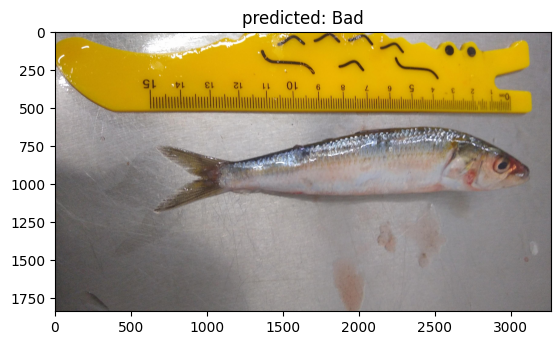

In [52]:
import matplotlib.pyplot as plt

img = cv2.imread(img_path)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb);
title = label_map[int(predictions[0])]
plt.title('predicted: '+title);

Karthik's version

In [ ]:
import numpy as np
rgb = np.array(rgb)
pred = fish_model.predict(rgb[:,:,::-1], conf=0.75)

In [ ]:
boxes = pred[0].boxes.xyxy
masks=pred[0].masks.xy
filtered_boxes = sorted(boxes, key=lambda bbox: bbox[0])
sorted_masks = [masks[i] for i in sorted(range(len(masks)), key=lambda x: boxes[x][0])]
shape = rgb.shape

In [ ]:
def get_fish_height(box):
  x1, y1, x2, y2 = map(float, box)
  h = abs(y2 - y1)
  w = abs(x2 - x1)
  if h<w: (h, w) = (w, h)
  d = math.sqrt(w**2 + h**2)
  return h, w, d

print(get_fish_height(filtered_boxes[0]))

(1574.859130859375, 373.18743896484375, 1618.4715464450665)


In [ ]:
def get_object_height_v2(img_path, model, conf=0.5, iou=0.7, seg=False):
    seg_img_list = None
    results = model(img_path, conf=conf, iou=iou, verbose=False)
    if len(results[0].boxes.cls) != 0:
        index = 0
        hp = int(results[0].boxes.xywh[index][3])
        wp = int(results[0].boxes.xywh[index][2])
        dp = int(math.hypot(hp, wp))
        if hp<wp: (hp, wp) = (wp, hp)
        obj_present = True
    else:
        hp, wp, dp = (0, 0, 0)
        obj_present = False
    return hp, wp, dp, obj_present

sh, sw, sd, scale = get_object_height_v2(img_path, scale_model)

In [ ]:
def extract_single_image_segment(img, mask_segment, shape, background='black'):
    height, width = shape[0], shape[1]
    segment = np.array(mask_segment, dtype=np.int32)
    segment = segment.reshape((-1, 2))
    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(mask, [segment], 255)
    masked_img = cv2.bitwise_and(img, img, mask=mask)
    x, y, w, h = cv2.boundingRect(segment)
    segment_image = np.zeros((h, w, 3), dtype=np.uint8)
    segment_image[0:h, 0:w] = masked_img[y:y+h, x:x+w]

    if background.lower() == 'black':
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [0, 0, 0]  # Set background to black
    elif background.lower() == 'white':
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [255, 255, 255]  # Set background to white
    else:
        raise ValueError("Invalid background color. Use 'black' or 'white'.")

    return segment_image


b_mask_image = extract_single_image_segment(rgb, sorted_masks[0], shape = shape, background='black')

In [ ]:
def fish_measures_v2(sh, sw, sd, box):
    # Predict with the scale model
    scale_hp, scale_wp, scale_dp, scale = sh, sw, sd, True
    # Predict with the fish model
    fish_hp, fish_wp, fish_dp, fish, fish_img_list = *get_fish_height(box), True, None

    try:
        scale_hcm = 13
        one_pixel_value = scale_hcm / scale_hp
        fish_hcm = int(fish_hp * one_pixel_value)
        fish_wcm = int(fish_wp * one_pixel_value)
        fish_dcm = int(fish_dp * one_pixel_value)
        scale_dcm = int(scale_dp * one_pixel_value)
        scale_wcm = int(scale_wp * one_pixel_value)
    except:
        (fish_hcm, fish_wcm, fish_dcm,
         scale_dcm, scale_wcm, one_pixel_value) = (0, 0, 0, 0, 0, 0)

    return (fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm,
            fish, scale, fish_img_list, one_pixel_value)

def single_img_data_v2(img_path, segment, sh, sw, sd, box):
    filename = os.path.basename(img_path)
    (fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm, fish, scale,
     fish_img_list, one_pixel_value) = fish_measures_v2(sh, sw, sd, box)
    data = []
    circumference, area = circumference_area(img = segment)
    if one_pixel_value != 0:
      circumference = int(circumference * one_pixel_value)
      area = int(area * one_pixel_value * one_pixel_value)
    data.append((filename, fish_hcm, fish_wcm, fish_dcm,
                scale_dcm, scale_wcm, one_pixel_value,
                scale, fish, circumference, area))
    return data

In [ ]:
single_img_data_v2(img_path, b_mask_image, sh, sw, sd, filtered_boxes[0])

[('20240326093504580_sardine_bad.jpeg',
  10,
  2,
  11,
  13,
  1,
  0.0068783068783068784,
  True,
  True,
  25,
  16)]

In [ ]:
single_img_data(img_path)

[('20240326093504580_sardine_bad.jpeg',
  10,
  2,
  11,
  13,
  1,
  0.0068783068783068784,
  True,
  True,
  25,
  16)]